# **04 · 데이터 주도 페르소나 — 단년의 '깔끔한 군집'은 7개년에서도 유지되는가**

### **"2025 단년에선 K-means가 4사분면을 재발견하는 듯 보였지만, 7개년 일관 측정으로 보면 다양성축이 이산·우편향이라 군집은 신뢰축만 가른다 — 4사분면은 emergent 구조가 아니라 규범적 프레임임을 입증하고, 그래서 규칙 운영(하이브리드)이 옳다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자**(90,996행) · 산출 = K-means 검증(ARI)·과적합 진단·프로파일

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가** · CRISP-DM **P4(Modeling)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 03의 **규칙기반 4사분면**(신뢰·다양성 중앙값 분할)은 데이터의 **자연 군집**인가 — K-means가 독립적으로 재발견하는가(ARI)?
> **Q2.** 단년(2025)에서 높아 보이던 '재발견'이 **7개년 전체·일관 측정**에서도 유지되는가 — 아니면 단년·측정 특수성에 기댄 **과적합**인가?
> **Q3.** 각 페르소나의 **인구·매체 프로파일**(연령·성별·매체 이용 폭)은 무엇이며 웹 데모 자가진단에 어떻게 쓰나?

→ 새 수학을 만들지 않는다. `news_health_features`의 K-means 유틸(`kmeans_personas`·`map_cluster_to_persona`·`adjusted_rand`)과 `health_index_panel`의 응답자 단위 신뢰·다양성을 **7개년 패널에 적용**해 검증·진단·프로파일로 입증하는 P4 단계다.

## **목차**

| § | 내용 | 핵심 질문 |
|:--:|------|-----------|
| 1 | 코어 2지표 + 다양성 이산성(pooled) | 군집 난이도 복선 |
| 2 | 표준화 + K 스윕 (+ [발견①]) | 군집 수 k |
| 3 | k=4 × 4사분면 교차검증 (+ DB·[발견②]) | 재발견하는가(ARI) |
| 4 | **단년 vs 7개년 ARI — 과적합 진단** (+ [발견③]) | 단년 낙관 교정 |
| 5 | 페르소나 프로파일(가중) (+ [발견④]) | 누가 각 유형인가 |
| 6 | 강건성표 | 설계 민감도 |
| 7 | 종합 · 한계(v1→v2) · 다음 | 결론·웹데모 |

## **변경 이력 — v1(2025 단년) → v2(7개년 패널)**

| 항목 | **v1** (이전 노트북) | **v2** (현재, A트랙) |
|------|----------------------|----------------------|
| 입력 | `load_2025()` — 2025 단년 6,000행 | `load_panel()` — 7개년 통합 패널(90,996행) |
| 신뢰·다양성 | `trust_index`(22문항)·`diversity_index`(0~12 richness) | `_trust_score_respondent`(cred 핵심3 pooled z)·`richness_fixed8`(공통 8매체, 0~8) |
| 핵심 결론 | "ARI 0.56 → 4사분면 재발견"(낙관) | **단년·측정 특수성 교정**: 일관 측정 시 ARI 0.13~0.41(약·불안정) → 4사분면은 **규범적 프레임** |
| K-means 역할 | 규칙 타당화 근거 | **한계 진단 도구**(다양성 이산성·신뢰축 지배 드러냄) → 하이브리드 더 강하게 정당화 |
| 가중 | `WT`(단년) | `wt_year_eq`(2022 표본지배 보정) |

> ⚠️ **해석 규약**: 임계는 **pooled(7개년 통합) 중앙값 고정**. 다양성축은 **formative·이산** → 절대수준 비교 금지·방향성만(06 §결과 R4). 산출 수치는 KPF 원자료 재검증 **전 셀 일치**(kpf-revalidation, 2026-07-11 · 입증 노트북 `12`)로 인용 자격 확정 — 자격등급은 p6-pdf-structure §3.

In [1]:
# ── 0. 셋업 — 7개년 패널 + 응답자 단위 신뢰·다양성(SSOT 재사용) ──
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "health_index_panel.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz
import news_health_features as nf      # K-means 유틸·persona_quadrant·PERSONA_LABELS
import health_index_panel as hp        # 응답자 단위 신뢰·패널 로드

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
def _kfont():
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm; break
        except Exception:
            continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()

panel = hp.load_panel()
W = panel["wt_year_eq"]                                  # 연도기여 균등화 가중

# 응답자 단위 신뢰·다양성 — 03(NCHI)과 동일 정의(thin 재사용)
T = hp._trust_score_respondent(panel)                    # cred 핵심3 pooled z → [1,100]
RICH = pd.to_numeric(panel["richness_fixed8"], errors="coerce")  # 공통 8매체 매체수(0~8)
D = nf._scale_1_100(RICH)                                # 다양성지수 [1,100]
NCHI = nf.nchi(T, D, "geometric")
persona_rule = nf.persona_quadrant(T, D)                 # pooled 중앙값 4사분면(운영 기준)

print(f"패널 N = {len(panel):,}행 · 연도 {hz.YEARS} · 가중 wt_year_eq")
print(f"유효(신뢰&다양성 동시) n = {int((T.notna() & D.notna()).sum()):,}")
print(f"임계(pooled 중앙값): 신뢰 {T.median():.1f} · 다양성 {D.median():.1f}")

패널 N = 90,996행 · 연도 [2019, 2020, 2021, 2022, 2023, 2024, 2025] · 가중 wt_year_eq
유효(신뢰&다양성 동시) n = 90,996
임계(pooled 중앙값): 신뢰 58.7 · 다양성 25.8


## 1. 코어 2지표 + 다양성 이산성 — 군집 난이도의 복선

군집 입력은 03에서 확정한 **2지표(신뢰·다양성)**다. 그런데 7개년 공통 고정풀 다양성(`richness_fixed8`)은 **0~8 정수**이고 분포가 1~3에 몰려 있다. 이 **이산·우편향**이 뒤(§3)에서 K-means가 다양성축을 깔끔히 가르지 못하는 원인이 된다 — 미리 분포를 본다.

In [2]:
dist = pd.DataFrame({"신뢰": T, "다양성": D, "NCHI": NCHI}).describe().round(2)
print("[pooled 분포 — 7개년 통합]")
print(dist.loc[["mean", "std", "min", "25%", "50%", "75%", "max"]].to_string())
print(f"\n신뢰 ↔ 다양성 상관 r = {T.corr(D):.3f}  → 두 축 거의 독립(03 재확인)")

vc = RICH.value_counts(dropna=False).sort_index()
print(f"\n[richness_fixed8 분포(매체수 0~8)] 중앙값 = {RICH.median():.0f}")
print(vc.to_string())
top3 = vc.loc[[1, 2, 3]].sum() / vc.sum() * 100
print(f"→ 1~3개에 {top3:.0f}% 집중(이산·우편향). 다양성 중앙값이 동률 덩어리 위에 놓여 군집 경계가 흐려진다.")

[pooled 분포 — 7개년 통합]
          신뢰     다양성   NCHI
mean   55.32   27.01  36.34
std    18.96   14.28  12.74
min     1.00    1.00   1.00
25%    42.34   13.38  28.01
50%    58.66   25.75  36.06
75%    67.09   38.12  44.02
max   100.00  100.00  91.33

신뢰 ↔ 다양성 상관 r = -0.040  → 두 축 거의 독립(03 재확인)

[richness_fixed8 분포(매체수 0~8)] 중앙값 = 2
richness_fixed8
0.0     3516
1.0    26056
2.0    33463
3.0    17893
4.0     6710
5.0     2600
6.0      593
7.0      137
8.0       28
→ 1~3개에 85% 집중(이산·우편향). 다양성 중앙값이 동률 덩어리 위에 놓여 군집 경계가 흐려진다.


## 2. 표준화 + K 스윕 — 엘보우·실루엣

표준화된 [신뢰, 다양성]에서 k=2~7 군집을 적합해 inertia·실루엣을 비교한다(90,996행 → 실루엣은 표본 추정). 통계지표가 특정 k를 강제하지 않으면 **해석가능성(4사분면 1:1 대응)**으로 k=4를 택해, 데이터 군집과 운영 규칙을 같은 틀에서 비교한다.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

both = pd.DataFrame({"trust": T, "diversity": D}).dropna()
Xz = StandardScaler().fit_transform(both)

rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xz)
    sil = silhouette_score(Xz, km.labels_, sample_size=5000, random_state=42)
    rows.append({"k": k, "inertia": round(km.inertia_, 0), "silhouette": round(sil, 3)})
sweep = pd.DataFrame(rows).set_index("k")
print("[K 스윕 — pooled 90,996행, 실루엣은 표본 5,000 추정]")
print(sweep.to_string())
print("\n→ 실루엣 평탄(통계지표가 k를 강제 안 함) → 해석가능성으로 k=4 채택(4사분면 정합).")

[K 스윕 — pooled 90,996행, 실루엣은 표본 5,000 추정]
    inertia  silhouette
k                      
2  121378.0       0.360
3   77550.0       0.381
4   63109.0       0.338
5   51263.0       0.368
6   43813.0       0.397
7   36778.0       0.416

→ 실루엣 평탄(통계지표가 k를 강제 안 함) → 해석가능성으로 k=4 채택(4사분면 정합).


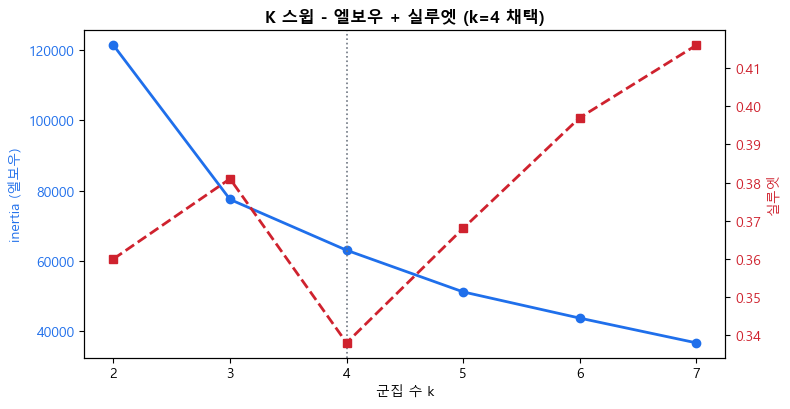

In [4]:
# [시각화] 엘보우(inertia) + 실루엣 이중축
fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.plot(sweep.index, sweep["inertia"], marker="o", color="#1f6feb", lw=2)
ax1.set_xlabel("군집 수 k"); ax1.set_ylabel("inertia (엘보우)", color="#1f6feb")
ax1.tick_params(axis="y", labelcolor="#1f6feb")
ax2 = ax1.twinx()
ax2.plot(sweep.index, sweep["silhouette"], marker="s", color="#cf222e", lw=2, ls="--")
ax2.set_ylabel("실루엣", color="#cf222e"); ax2.tick_params(axis="y", labelcolor="#cf222e")
ax1.axvline(4, color="#6e7681", ls=":", lw=1.2)
ax1.set_title("K 스윕 - 엘보우 + 실루엣 (k=4 채택)", fontsize=12, weight="bold")
plt.tight_layout(); plt.show()

#### **[발견 ①] 실루엣은 평탄 — 통계가 아니라 해석가능성이 k를 정한다**

inertia는 매끈하게 감소하고 실루엣은 좁은 띠에서 움직여 **뚜렷한 최적 k가 없다**(두 축이 연속적으로 퍼진 분포의 전형). k는 **외부 기준**으로 정해야 하며, 03의 신뢰·다양성 4사분면과 1:1 대응하는 **k=4**를 채택한다. (실루엣이 k를 강제하지 못한다는 것 자체가, 데이터에 '딱 4덩어리'가 박혀있지 않을 수 있다는 §3의 복선이다.)

→ **① K 스윕 — 완료(k=4 채택). 다음은 그 군집이 규칙 4사분면을 재발견하는지.**

## 3. k=4 군집 × 4사분면 교차검증 — 재발견하는가?

K-means(데이터 주도)가 규칙기반 4사분면(pooled 중앙값)을 얼마나 재발견하는지 군집 중심·교차표·**ARI(조정 랜드지수, 라벨명 무관 파티션 일치도)**로 본다. ARI는 0이면 무작위, 1이면 완전 일치다.

In [5]:
from sklearn.metrics import adjusted_rand_score

labels, centers, km = nf.kmeans_personas(T, D, k=4)
cen = centers.copy()
cen["대응_사분면"] = [nf.PERSONA_LABELS[(row.trust >= T.median(), row.diversity >= D.median())]
                      for _, row in cen.iterrows()]
print("[군집 중심 (원척도) → 대응 사분면]")
print(cen.round(1).to_string())

print("\n[K-means 군집 × 규칙 4사분면 교차표]")
print(pd.crosstab(labels, persona_rule).to_string())

m = persona_rule.notna() & labels.notna()
ari = adjusted_rand_score(persona_rule[m], labels[m])   # 파티션 일치도(라벨명 무관)
quads = set(cen["대응_사분면"])
print(f"\n파티션 ARI(규칙 4사분면 vs K-means k=4) = {ari:.3f}")
print(f"군집 중심이 덮는 사분면 = {sorted(quads)}  (4개 중 {len(quads)}개)")
print("→ 일부 사분면(특히 신뢰편향형=고신뢰·저다양)은 별도 군집으로 분리되지 않음.")

[군집 중심 (원척도) → 대응 사분면]
   trust  diversity   대응_사분면
0   52.8       48.0  비판적 탐색형
1   55.5       16.9    이중취약형
2   76.1       25.9  건강한 소비자
3   29.3       24.8    이중취약형

[K-means 군집 × 규칙 4사분면 교차표]
col_0    건강한 소비자  비판적 탐색형  신뢰편향형  이중취약형
cluster                                
0           7117    10521      0      0
1           4489     6581   8817   9729
2          19021        0   6133      0
3              0    13695      0   4893

파티션 ARI(규칙 4사분면 vs K-means k=4) = 0.244
군집 중심이 덮는 사분면 = ['건강한 소비자', '비판적 탐색형', '이중취약형']  (4개 중 3개)
→ 일부 사분면(특히 신뢰편향형=고신뢰·저다양)은 별도 군집으로 분리되지 않음.


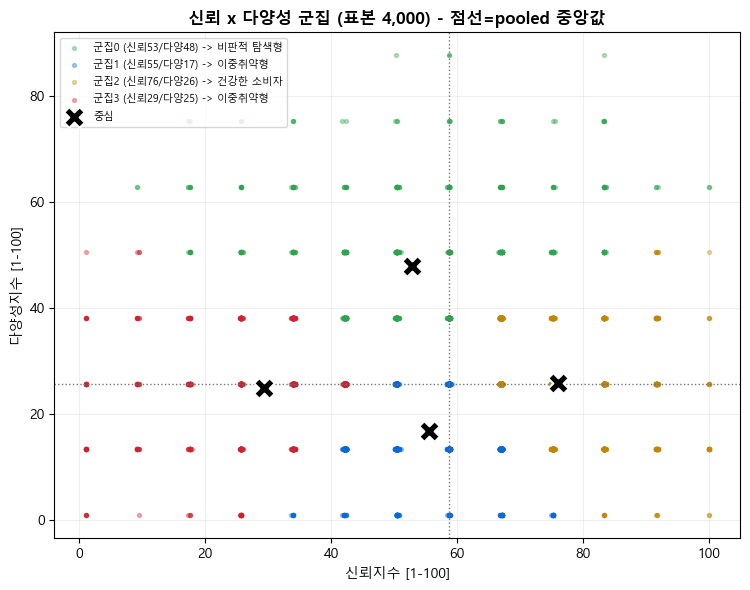

In [6]:
# [시각화] 신뢰x다양성 산점도(군집색) + 중심 — 표본 4,000. 군집이 '신뢰축'으로 갈림을 확인
samp = both.sample(n=min(4000, len(both)), random_state=42)
lab_s = labels.reindex(samp.index)
palette = ["#2da44e", "#0969da", "#bf8700", "#cf222e"]
fig, ax = plt.subplots(figsize=(7.6, 6))
for c in sorted(lab_s.dropna().unique()):
    mm = lab_s == c
    rc = cen.loc[int(c)]
    ax.scatter(samp.loc[mm, "trust"], samp.loc[mm, "diversity"], s=8, alpha=0.35,
               color=palette[int(c) % 4],
               label=f"군집{int(c)} (신뢰{rc.trust:.0f}/다양{rc.diversity:.0f}) -> {rc['대응_사분면']}")
ax.scatter(centers["trust"], centers["diversity"], marker="X", s=220,
           color="black", edgecolor="white", linewidth=1.5, zorder=5, label="중심")
ax.axvline(T.median(), color="#6e7681", ls=":", lw=1); ax.axhline(D.median(), color="#6e7681", ls=":", lw=1)
ax.set_xlabel("신뢰지수 [1-100]"); ax.set_ylabel("다양성지수 [1-100]")
ax.set_title("신뢰 x 다양성 군집 (표본 4,000) - 점선=pooled 중앙값", fontsize=12, weight="bold")
ax.legend(fontsize=7.5, loc="upper left"); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

> #### 🟦 Decision Box — 재발견이 약한데 왜 4사분면을 계속 쓰나? (하이브리드)
>
> **결정**: 운영·웹데모 자가진단은 **규칙기반 4사분면**(pooled 중앙값)을 쓰고, K-means는 **한계 진단 도구**로만 둔다.
>
> **근거**: ARI가 낮다는 것은 "4사분면이 틀렸다"가 아니라 **"데이터에 자연적으로 박힌 4덩어리가 아니다"**라는 뜻이다. 다양성축이 이산·우편향(§1)이라 비지도 군집은 분산이 큰 **신뢰축을 우선 가르고** 다양성 경계는 무시한다. 4사분면은 *해석·개입을 위한 규범적 프레임*으로서 가치가 있고(재현·설명 명확), 자가진단 운영에 적합하다. K-means는 이 프레임이 emergent가 아님을 **정직하게 드러내는 역할**이다.
>
> **대안 기각**: ① K-means 군집을 운영 페르소나로 사용 → 신뢰편향형 미분리·표본의존, 자가진단 불가. ② "ARI 낮으니 페르소나 폐기" → 규범적 프레임의 효용(개입 타게팅·설명)을 버리는 과반응. 둘 다 기각.

#### **[발견 ②] K-means는 4사분면을 '약하게'만 재발견 — 다양성 이산성이 신뢰축 분할을 부른다**

7개년 pooled에서 K-means k=4의 파티션 ARI는 **0.2대(약한 일치)**에 그치고, 군집 중심은 4사분면을 **온전히 덮지 못한다**(신뢰편향형이 독립 군집으로 분리되지 않고, 저다양 영역에 군집이 중복 배치). 산점도에서 보듯 군집은 주로 **신뢰축(가로)**을 따라 갈라진다 — §1에서 본 다양성의 이산·우편향 때문에 세로축 경계가 흐리기 때문이다. 즉 **4사분면은 데이터가 스스로 만든 구조가 아니라, 해석을 위해 부여한 규범적 격자**다.

→ **② 교차검증 — 완료(재발견 약함). 그렇다면 v1(2025)의 'ARI 0.56 재발견'은 무엇이었나?**

## 4. 단년 vs 7개년 ARI — 단년 낙관의 과적합 진단

v1은 2025 단년·옛 측정(22문항 신뢰·12문항 다양성)에서 **ARI 0.56**으로 "4사분면 재발견"을 주장했다. 같은 절차를 **7개년 일관 측정(고정풀 8매체)**으로 연도마다 돌려, 그 결론이 **데이터·측정을 넘어 유지되는지** 본다. 전체 데이터로 봐야 단년 특수성(과적합)을 식별할 수 있다.

In [7]:
# 연도별 파티션 ARI(일관 측정: cred3 신뢰 · fixed8 다양성)
rows = []
for y in hz.YEARS:
    idx = panel.index[panel["year"] == y]
    Ty, Dy = T[idx], D[idx]
    pr = nf.persona_quadrant(Ty, Dy)
    lb, _, _ = nf.kmeans_personas(Ty, Dy, k=4)
    mm = pr.notna() & lb.notna()
    rows.append({"year": y, "n": int(mm.sum()),
                 "ARI": round(adjusted_rand_score(pr[mm], lb[mm]), 3)})
ari_year = pd.DataFrame(rows).set_index("year")
print("[연도별 파티션 ARI — 일관 측정(cred3·fixed8)]")
print(ari_year.to_string())
print(f"\npooled ARI = {ari:.3f}  |  연도 범위 {ari_year['ARI'].min():.3f}~{ari_year['ARI'].max():.3f}")
print(f"참고: v1(2025·옛 측정 22문항·12문항) ARI = 0.561  vs  본 분석 2025(일관 측정) = {ari_year.loc[2025,'ARI']:.3f}")
print("→ 일관 측정으로 보면 어느 연도도 '강한 재발견'(>0.5)에 못 미치고, 연도별 0.13~0.41로 불안정.")

[연도별 파티션 ARI — 일관 측정(cred3·fixed8)]
          n    ARI
year              
2019   5040  0.312
2020   5010  0.367
2021   5010  0.253
2022  58936  0.199
2023   5000  0.316
2024   6000  0.406
2025   6000  0.128

pooled ARI = 0.244  |  연도 범위 0.128~0.406
참고: v1(2025·옛 측정 22문항·12문항) ARI = 0.561  vs  본 분석 2025(일관 측정) = 0.128
→ 일관 측정으로 보면 어느 연도도 '강한 재발견'(>0.5)에 못 미치고, 연도별 0.13~0.41로 불안정.


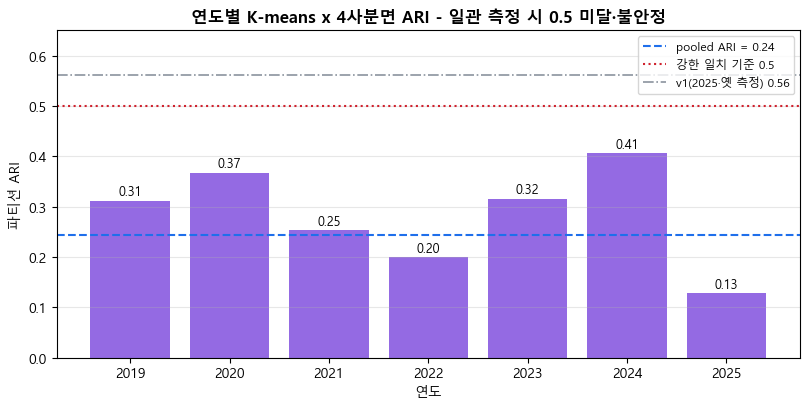

In [8]:
# [시각화] 연도별 ARI 막대 + pooled/0.5 기준선
fig, ax = plt.subplots(figsize=(8.2, 4.2))
bars = ax.bar(ari_year.index.astype(str), ari_year["ARI"], color="#8250df", alpha=0.85)
for b, v in zip(bars, ari_year["ARI"]):
    ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax.axhline(ari, color="#1f6feb", ls="--", lw=1.5, label=f"pooled ARI = {ari:.2f}")
ax.axhline(0.5, color="#cf222e", ls=":", lw=1.5, label="강한 일치 기준 0.5")
ax.axhline(0.561, color="#8b949e", ls="-.", lw=1.2, label="v1(2025·옛 측정) 0.56")
ax.set_title("연도별 K-means x 4사분면 ARI - 일관 측정 시 0.5 미달·불안정", fontsize=12, weight="bold")
ax.set_xlabel("연도"); ax.set_ylabel("파티션 ARI"); ax.set_ylim(0, 0.65)
ax.legend(fontsize=8.5); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

#### **[발견 ③] 전체 데이터가 단년 낙관을 교정한다 — 'ARI 0.56'은 단년·측정 특수성**

일관 측정으로 7개년을 보면 ARI는 연도별 **0.13~0.41, pooled 0.2대**로 어느 해도 강한 일치(0.5)에 닿지 못하고 해마다 흔들린다. v1의 2025 단년 0.56은 (a) 더 세분된 옛 다양성 측정(12문항)과 (b) 단년 적합이 겹쳐 만든 **낙관**이었다 — 동일한 2025라도 일관 측정으로는 0.13에 불과하다. 이것이 **전체 데이터로 분석해야 하는 이유**다: 단일 연도만 보면 "데이터가 4집단으로 자연히 나뉜다"는 과적합된 결론을 내리기 쉽지만, 7개년·일관 측정은 그것이 **규범적 프레임**임을 드러낸다(편향·과적합의 정직한 식별).

→ **③ 과적합 진단 — 완료. 페르소나는 '발견'이 아니라 '설계'이므로, 이제 각 유형이 누구인지 본다.**

## 5. 페르소나 프로파일 (가중) — 누가 각 유형이며 어떻게 개입하나

운영 기준인 **규칙기반 4사분면**으로 인구(연령·성별)·매체 이용을 7개년 가중 프로파일링한다. 연령은 패널 `age`(수치)를 6개 대(代)로 비닝, 매체는 고정풀 8매체 이용률(가중%).

In [9]:
order = ["건강한 소비자", "비판적 탐색형", "신뢰편향형", "이중취약형"]
age = pd.to_numeric(panel["age"], errors="coerce")
ageb = pd.cut(age, bins=[0, 29, 39, 49, 59, 69, 200],
              labels=["19-29", "30-39", "40-49", "50-59", "60-69", "70+"])
female = (pd.to_numeric(panel["sex"], errors="coerce") == 2).astype(float)

prof = []
for lab in order:
    mm = (persona_rule == lab); ww = W[mm]
    prof.append({
        "페르소나": lab,
        "가중%": round(W[mm].sum() / W.sum() * 100, 1),
        "n": int(mm.sum()),
        "평균연령": round(nf.wmean(age[mm], ww), 1),
        "여성%": round(nf.wmean(female[mm], ww) * 100, 1),
        "신뢰": round(nf.wmean(T[mm], ww), 1),
        "다양성": round(nf.wmean(D[mm], ww), 1),
        "NCHI": round(nf.wmean(NCHI[mm], ww), 1),
        "평균매체수": round(nf.wmean(RICH[mm], ww), 2),
    })
prof = pd.DataFrame(prof).set_index("페르소나")
print("[페르소나 프로파일 (7개년 가중)]")
print(prof.to_string())

[페르소나 프로파일 (7개년 가중)]
          가중%      n  평균연령   여성%    신뢰   다양성  NCHI  평균매체수
페르소나                                                     
건강한 소비자  37.3  30627  47.2  47.4  69.2  35.1  48.6   2.75
비판적 탐색형  33.3  30797  46.9  45.7  40.8  35.2  36.7   2.76
신뢰편향형    15.5  14950  55.9  61.3  70.3  12.1  28.3   0.90
이중취약형    14.0  14622  50.6  56.2  40.9  11.7  20.9   0.87


[페르소나별 매체 이용률 (7개년 가중%, 고정풀 8매체)]
         종이신문   잡지    TV   라디오   인터넷   메신저   SNS   동영상
건강한 소비자  13.8  2.7  90.8  10.9  95.9  21.6  14.4  31.8
비판적 탐색형  13.7  2.7  88.3  12.9  96.3  19.9  15.7  36.5
신뢰편향형     0.4  0.0  65.5   0.4  29.0   0.1   0.0   0.1
이중취약형     0.9  0.0  50.7   0.3  41.9   0.0   0.0   0.3


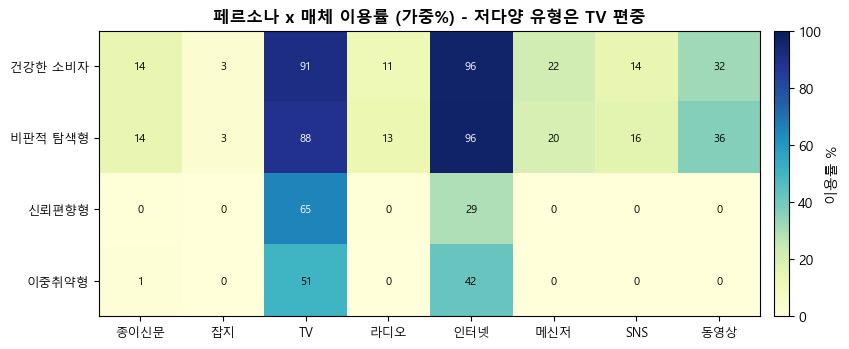

In [10]:
# 페르소나 x 매체 이용률(고정풀 8매체, 가중%) — 히트맵
USE8 = ["use_paper", "use_magazine", "use_tv", "use_radio",
        "use_internet", "use_messenger", "use_sns", "use_video"]
ulbl = ["종이신문", "잡지", "TV", "라디오", "인터넷", "메신저", "SNS", "동영상"]
mat = []
for lab in order:
    mm = (persona_rule == lab); ww = W[mm]
    mat.append([nf.wmean(pd.to_numeric(panel[c], errors="coerce")[mm], ww) * 100 for c in USE8])
mat = pd.DataFrame(mat, index=order, columns=ulbl)
print("[페르소나별 매체 이용률 (7개년 가중%, 고정풀 8매체)]")
print(mat.round(1).to_string())

# [시각화] 히트맵
fig, ax = plt.subplots(figsize=(8.6, 3.6))
im = ax.imshow(mat.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(ulbl))); ax.set_xticklabels(ulbl, fontsize=9)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=9)
for i in range(len(order)):
    for j in range(len(ulbl)):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                color="white" if v > 55 else "black")
ax.set_title("페르소나 x 매체 이용률 (가중%) - 저다양 유형은 TV 편중", fontsize=12, weight="bold")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="이용률 %")
plt.tight_layout(); plt.show()

#### **[발견 ④] 저다양 두 유형(신뢰편향·이중취약)은 고령·TV 편중 — 개입 타깃이 분명**

고다양 두 유형(건강한 소비자·비판적 탐색형)은 평균연령이 낮고 인터넷·동영상까지 매체 폭이 넓다. 반면 **저다양 두 유형(신뢰편향형·이중취약형)은 고령 비중이 크고 사실상 TV 중심 소수 매체에 편중**된다. 신뢰편향형은 신뢰는 높되 매체가 좁은 '편식', 이중취약형은 신뢰·다양성 모두 낮다. §3~§4가 보였듯 이 경계는 emergent가 아니라 규범적이지만, **개입 타게팅 도구로서는 유효**하다 — 다양성 확장 캠페인은 **고령·TV 편중 집단**에 초점을 둬야 한다(웹 데모 처방 카드 근거).

→ **④ 프로파일 — 완료(개입 대상 식별).**

## 6. 강건성표 — 설계 선택 민감도

임계(중앙/평균)·집계(기하/산술)·k·표준화를 흔들어 분포·NCHI·군집 안정성을 점검한다.

In [11]:
def quad_dist(t_thr, d_thr):
    p = nf.persona_quadrant(T, D, t_thr, d_thr)
    return {lab: round(W[p == lab].sum() / W.sum() * 100, 1) for lab in order}

rob = pd.DataFrame({"중앙값임계": quad_dist(T.median(), D.median()),
                    "평균임계":   quad_dist(T.mean(),   D.mean())}).T
print("[임계 민감도: 4사분면 가중%]")
print(rob.to_string())

agg = pd.DataFrame({
    "기하평균": nf.nchi(T, D, "geometric").describe()[["mean", "50%", "std"]],
    "산술평균": nf.nchi(T, D, "arithmetic").describe()[["mean", "50%", "std"]],
}).round(2)
print("\n[집계 민감도: NCHI 분포]")
print(agg.to_string())

[임계 민감도: 4사분면 가중%]
       건강한 소비자  비판적 탐색형  신뢰편향형  이중취약형
중앙값임계     37.3     33.3   15.5   14.0
평균임계      19.9     15.1   36.9   28.2

[집계 민감도: NCHI 분포]
       기하평균   산술평균
mean  36.34  41.16
50%   36.06  42.20
std   12.74  11.64


In [12]:
from sklearn.preprocessing import MinMaxScaler
Xmm = MinMaxScaler().fit_transform(both)
rob_k = []
for name, Xs in [("z표준화", Xz), ("minmax", Xmm)]:
    for k in (3, 4, 5):
        lb = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Xs)
        rob_k.append({"표준화": name, "k": k,
                      "실루엣": round(silhouette_score(Xs, lb, sample_size=5000, random_state=42), 3)})
print("[k·표준화 민감도: 실루엣]")
print(pd.DataFrame(rob_k).pivot(index="k", columns="표준화", values="실루엣").to_string())
print("\n→ 실루엣은 k·표준화에 거의 불변(평탄). 4사분면 분포는 임계 선택에 민감하나")
print("  순위(건강 > 비판 ~ 신뢰편향 > 이중취약)는 불변. ARI가 낮은 것과 일관(자연군집 약함).")

[k·표준화 민감도: 실루엣]
표준화  minmax   z표준화
k                 
3     0.387  0.381
4     0.380  0.338
5     0.363  0.368

→ 실루엣은 k·표준화에 거의 불변(평탄). 4사분면 분포는 임계 선택에 민감하나
  순위(건강 > 비판 ~ 신뢰편향 > 이중취약)는 불변. ARI가 낮은 것과 일관(자연군집 약함).


## 7. 종합 · 한계(v1 → v2) · 다음

### 종합
- **재발견 검정(ARI)**: 일관 측정 7개년에서 K-means k=4의 4사분면 재발견은 **약·불안정**(연도 0.13~0.41·pooled 0.2대, 0.5 미달).
- **과적합 진단**: v1의 단년 ARI 0.56은 옛 측정+단년 적합의 낙관 → 전체 데이터·일관 측정이 이를 교정. **4사분면 = 규범적 프레임**(emergent 아님).
- **그래도 유효**: 규범적이어도 재현·설명·개입 타게팅 도구로 쓸 만함. 저다양 두 유형은 **고령·TV 편중** → 다양성 개입 우선 대상.

### 한계 (v1 → v2 로드맵)
| 항목 | v2 처리 | 한계 | v3 보완 방향 |
|------|--------|------|-------------|
| 다양성 측정 | 고정풀 8매체(이산 0~8) | 이산·우편향 → 자연 군집 형성 약함 | 빈도·강도 등 연속 다양성 지표 보강 검토 |
| 군집 입력 | 2지표(신뢰·다양성) | 검증·회피 보조지표 패널 미수집 | 7개년 공통 보조지표 확보 시 재검토 |
| 페르소나 | 규칙 4사분면(규범적) | emergent 아님(ARI 낮음) | 규칙 운영 유지·K-means는 진단용 |

> ⚠️ 다양성·페르소나 절대 비중은 formative·이산 한계 → 종단 해석은 방향성 위주(06 §결과 R4).
> 산출 수치는 KPF 원자료 재검증 **전 셀 일치**([kpf-revalidation](../docs/design/kpf-revalidation.md), 2026-07-11 · 입증 노트북 `12`)와 측정동등 검정(`21`~`23`) 통과로 인용 자격이 확정됐다 — 자격등급은 [p6-pdf-structure §3](../docs/report/p6-pdf-structure.md).

### 다음 — 웹 데모 자가진단 입력 사양
- **입력**: 신뢰(cred 핵심3 축약 문항, 5점) · 다양성(최근 1주 이용 매체유형 체크, 고정풀 8종)
- **산출**: 신뢰 z평균 → [1,100] · Richness(체크 수) → [1,100] → **pooled 중앙값 4사분면** 배정(규범적 프레임임을 고지)
- **결과 카드(처방)**: 건강한 소비자=유지·교차검증 / 비판적 탐색형=신뢰 원출처 고정 / 신뢰편향형=안 보던 매체 1종 추가 / 이중취약형=쉬운 1매체부터 신뢰·확장 동시 코칭

---
> **재현**: `python src/harmonize.py`(패널) → 본 노트북(K-means·진단·프로파일). K-means 유틸·지수 수학은 `news_health_features`·`health_index_panel` SSOT, 노트북은 적용·입증.